# Session 9: Synthetic Data Generation and RAG Evaluation with LangSmith

In the following notebook we'll explore a use-case for RAGAS' synthetic testset generation workflow, and use it to evaluate and iterate on a RAG pipeline with LangSmith!

**Learning Objectives:**
- Understand Ragas' knowledge graph-based synthetic data generation workflow
- Generate synthetic test sets with different query synthesizer types
- Load synthetic data into LangSmith for evaluation
- Evaluate a RAG chain using LangSmith evaluators
- Iterate on RAG pipeline parameters and measure the impact

## Table of Contents:

- **Breakout Room #1:** Synthetic Data Generation with Ragas
  - Task 1: Dependencies and API Keys
  - Task 2: Data Preparation and Knowledge Graph Construction
  - Task 3: Generating Synthetic Test Data
  - Question #1 & Question #2
  - 🏗️ Activity #1: Custom Query Distribution

- **Breakout Room #2:** RAG Evaluation with LangSmith
  - Task 4: LangSmith Dataset Setup
  - Task 5: Building a Basic RAG Chain
  - Task 6: Evaluating with LangSmith
  - Task 7: Modifying the Pipeline and Re-Evaluating
  - Question #3 & Question #4
  - 🏗️ Activity #2: Analyze Evaluation Results

---
# 🤝 Breakout Room #1
## Synthetic Data Generation with Ragas

## Task 1: Dependencies and API Keys

We'll need to install a number of API keys and dependencies, since we'll be leveraging a number of great technologies for this pipeline!

1. OpenAI's endpoints to handle the Synthetic Data Generation
2. OpenAI's Endpoints for our RAG pipeline and LangSmith evaluation
3. QDrant as our vectorstore
4. LangSmith for our evaluation coordinator!

Let's install and provide all the required information below!

## Dependencies and API Keys:

### NLTK Import

To prevent errors that may occur based on OS - we'll import NLTK and download the needed packages to ensure correct handling of data.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /Users/annie/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/annie/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [2]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

We'll also want to set a project name to make things easier for ourselves.

In [3]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OpenAI's API Key!

In [4]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data using two complementary guides — a Health & Wellness Guide covering exercise, nutrition, sleep, and stress management, and a Mental Health & Psychology Handbook covering mental health conditions, therapeutic approaches, resilience, and daily mental health practices. The topical overlap between documents helps RAGAS build rich cross-document relationships in the knowledge graph.

Next, let's load our data into a familiar LangChain format using the `TextLoader`.

In [5]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader

loader = DirectoryLoader("data/", glob="*.txt", loader_cls=TextLoader)
docs = loader.load()
print(f"Loaded {len(docs)} documents: {[d.metadata['source'] for d in docs]}")

Loaded 2 documents: ['data/MentalHealthGuide.txt', 'data/HealthWellnessGuide.txt']


### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Unrolled SDG

In [6]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

Next, we're going to instantiate our Knowledge Graph.

This graph will contain N number of nodes that have M number of relationships. These nodes and relationships (AKA "edges") will define our knowledge graph and be used later to construct relevant questions and responses.

In [7]:
from ragas.testset.graph import KnowledgeGraph

kg = KnowledgeGraph()
kg

KnowledgeGraph(nodes: 0, relationships: 0)

In [8]:
from langsmith import Client
client = Client()
# This will fail fast if your key is invalid
print(client.list_datasets(limit=1))

<generator object Client.list_datasets at 0x14790d800>


The first step we're going to take is to simply insert each of our full documents into the graph. This will provide a base that we can apply transformations to.

In [9]:
from ragas.testset.graph import Node, NodeType

for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )
kg

KnowledgeGraph(nodes: 2, relationships: 0)

Now, we'll apply the *default* transformations to our knowledge graph. This will take the nodes currently on the graph and transform them based on a set of [default transformations](https://docs.ragas.io/en/latest/references/transforms/#ragas.testset.transforms.default_transforms).

These default transformations are dependent on the corpus length, in our case:

- Producing Summaries -> produces summaries of the documents
- Extracting Headlines -> finding the overall headline for the document
- Theme Extractor -> extracts broad themes about the documents

It then uses cosine-similarity and heuristics between the embeddings of the above transformations to construct relationships between the nodes.

In [10]:
from ragas.testset.transforms import default_transforms, apply_transforms

transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
kg

Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/7 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/16 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

KnowledgeGraph(nodes: 9, relationships: 16)

We can save and load our knowledge graphs as follows.

In [11]:
kg.save("usecase_data_kg.json")
usecase_data_kg = KnowledgeGraph.load("usecase_data_kg.json")
usecase_data_kg

KnowledgeGraph(nodes: 9, relationships: 16)

Using our knowledge graph, we can construct a "test set generator" - which will allow us to create queries.

In [13]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=usecase_data_kg)

However, we'd like to be able to define the kinds of queries we're generating - which is made simple by Ragas having pre-created a number of different "QuerySynthesizer"s.

Each of these Synthetsizers is going to tackle a separate kind of query which will be generated from a scenario and a persona.

In essence, Ragas will use an LLM to generate a persona of someone who would interact with the data - and then use a scenario to construct a question from that data and persona.

In [14]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

## ❓ Question #1:

What are the three types of query synthesizers doing? Describe each one in simple terms.

##### Answer:
A query synthesizer is responsible for converting information in the knowledge graph into test queries. The three query synthesizers above are going to create the different types of test questions, with the proportions specified by the second entry in the tuple. 50% of the questions will be concrete questions requiring a only single chunk on context from the graph (a "single hop" for SingleHopSpecific), 25% of questions will be more complex and require multiple chunks of context (multiple hops in the graph) yet still be concrete questions (MultiHopSpecific), and 25% will be more complex abstract questions requiring information synthesis rather than just fact retrieval (MultiHopAbstract).

Finally, we can use our `TestSetGenerator` to generate our testset!

In [15]:
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

Generating personas:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,In United States how mental health affect well...,[The Mental Health and Psychology Handbook A P...,Mental health in the United States affects wel...,single_hop_specifc_query_synthesizer
1,What is CBT?,[PART 2: THERAPEUTIC APPROACHES Chapter 4: Cog...,Cognitive Behavioral Therapy (CBT) is one of t...,single_hop_specifc_query_synthesizer
2,How does zinc relate to wellness?,[Write letters to or from your future self Jou...,Zinc is a nutrient mentioned in the context of...,single_hop_specifc_query_synthesizer
3,How social media affects your mental health an...,[social interactions How to set and maintain b...,Social media can impact mental health by lower...,single_hop_specifc_query_synthesizer
4,What role do fats play in a balanced diet acco...,[PART 2: NUTRITION AND DIET Chapter 4: Fundame...,Fats are necessary for hormone production and ...,single_hop_specifc_query_synthesizer
5,how do I build a workout routine with exercise...,[<1-hop>\n\nThe Personal Wellness Guide A Comp...,"According to the Personal Wellness Guide, buil...",multi_hop_abstract_query_synthesizer
6,How can understanding habit formation and impl...,[<1-hop>\n\nPART 2: NUTRITION AND DIET Chapter...,"Understanding habit formation, including the h...",multi_hop_abstract_query_synthesizer
7,How do neurobiological effects of exercise and...,[<1-hop>\n\nWrite letters to or from your futu...,The context explains that exercise increases n...,multi_hop_abstract_query_synthesizer
8,How does Chapter 8 about sleep quality relate ...,[<1-hop>\n\nPART 2: NUTRITION AND DIET Chapter...,Chapter 8 explains that good sleep hygiene and...,multi_hop_specific_query_synthesizer
9,"How does vitamin D, as a key vitamin discussed...",[<1-hop>\n\nWrite letters to or from your futu...,"Vitamin D, obtained from sunlight and fortifie...",multi_hop_specific_query_synthesizer


### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [16]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/8 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/18 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [15]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,What are the recommended exercises and strateg...,[The Personal Wellness Guide A Comprehensive R...,The provided context does not include specific...,single_hop_specifc_query_synthesizer
1,What does Stage 2 of sleep involve in the slee...,[PART 3: SLEEP AND RECOVERY Chapter 7: The Sci...,Stage 2 involves a drop in body temperature an...,single_hop_specifc_query_synthesizer
2,What information does Chapter 18 cover regardi...,[PART 5: BUILDING HEALTHY HABITS Chapter 13: T...,Chapter 18 discusses strategies to boost immun...,single_hop_specifc_query_synthesizer
3,How does the World Health Organization define ...,[The Mental Health and Psychology Handbook A P...,"According to the World Health Organization, me...",single_hop_specifc_query_synthesizer
4,how can exercise for common problems like lowe...,[<1-hop>\n\nThe Personal Wellness Guide A Comp...,The wellness guide explains that gentle exerci...,multi_hop_abstract_query_synthesizer
5,How can incorporating mindfulness and social c...,[<1-hop>\n\nhour before bed - No caffeine afte...,Incorporating mindfulness and social connectio...,multi_hop_abstract_query_synthesizer
6,How can improving face-to-face interactions an...,[<1-hop>\n\nhour before bed - No caffeine afte...,Improving face-to-face interactions by engagin...,multi_hop_abstract_query_synthesizer
7,How can I improve my emotional intelligence an...,[<1-hop>\n\nhour before bed - No caffeine afte...,To improve emotional intelligence and manage c...,multi_hop_abstract_query_synthesizer
8,how chapter 7 and 17 connect about sleep and h...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,"chapter 7 talks about sleep and recovery, expl...",multi_hop_specific_query_synthesizer
9,H0w c4n I bUild a he4lthy m0rn1ng r0utine (cha...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,To build a healthy morning routine that improv...,multi_hop_specific_query_synthesizer


In [ ]:
for i, node in enumerate(kg.nodes):
    node_type = str(node.type).split('.')[-1]  # Get just the type name

    if 'page_content' in node.properties:
        content = node.properties['page_content'][:80] + '...'
    elif 'summary' in node.properties:
        content = node.properties['summary'][:80] + '...'
    else:
        content = str(list(node.properties.keys()))

    print(f"Node {i} [{node_type}]: {content}")

Node 0 [DOCUMENT]: The Mental Health and Psychology Handbook
A Practical Guide to Understanding and...
Node 1 [DOCUMENT]: The Personal Wellness Guide
A Comprehensive Resource for Health and Well-being

...
Node 2 [CHUNK]: The Mental Health and Psychology Handbook A Practical Guide to Understanding and...
Node 3 [CHUNK]: PART 2: THERAPEUTIC APPROACHES Chapter 4: Cognitive Behavioral Therapy (CBT) Cog...
Node 4 [CHUNK]: Write letters to or from your future self Journaling best practices: - Write reg...
Node 5 [CHUNK]: social interactions How to set and maintain boundaries: - Identify your limits a...
Node 6 [CHUNK]: PART 2: NUTRITION AND DIET Chapter 4: Fundamentals of Healthy Eating A balanced ...
Node 7 [CHUNK]: 13: The Science of Habit Formation Habits are behaviors that become automatic th...
Node 8 [CHUNK]: The Personal Wellness Guide A Comprehensive Resource for Health and Well-being P...


/var/folders/vv/l_xmncsj59gbr7ptc7h1ghvm0000gn/T/ipykernel_33699/550404539.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


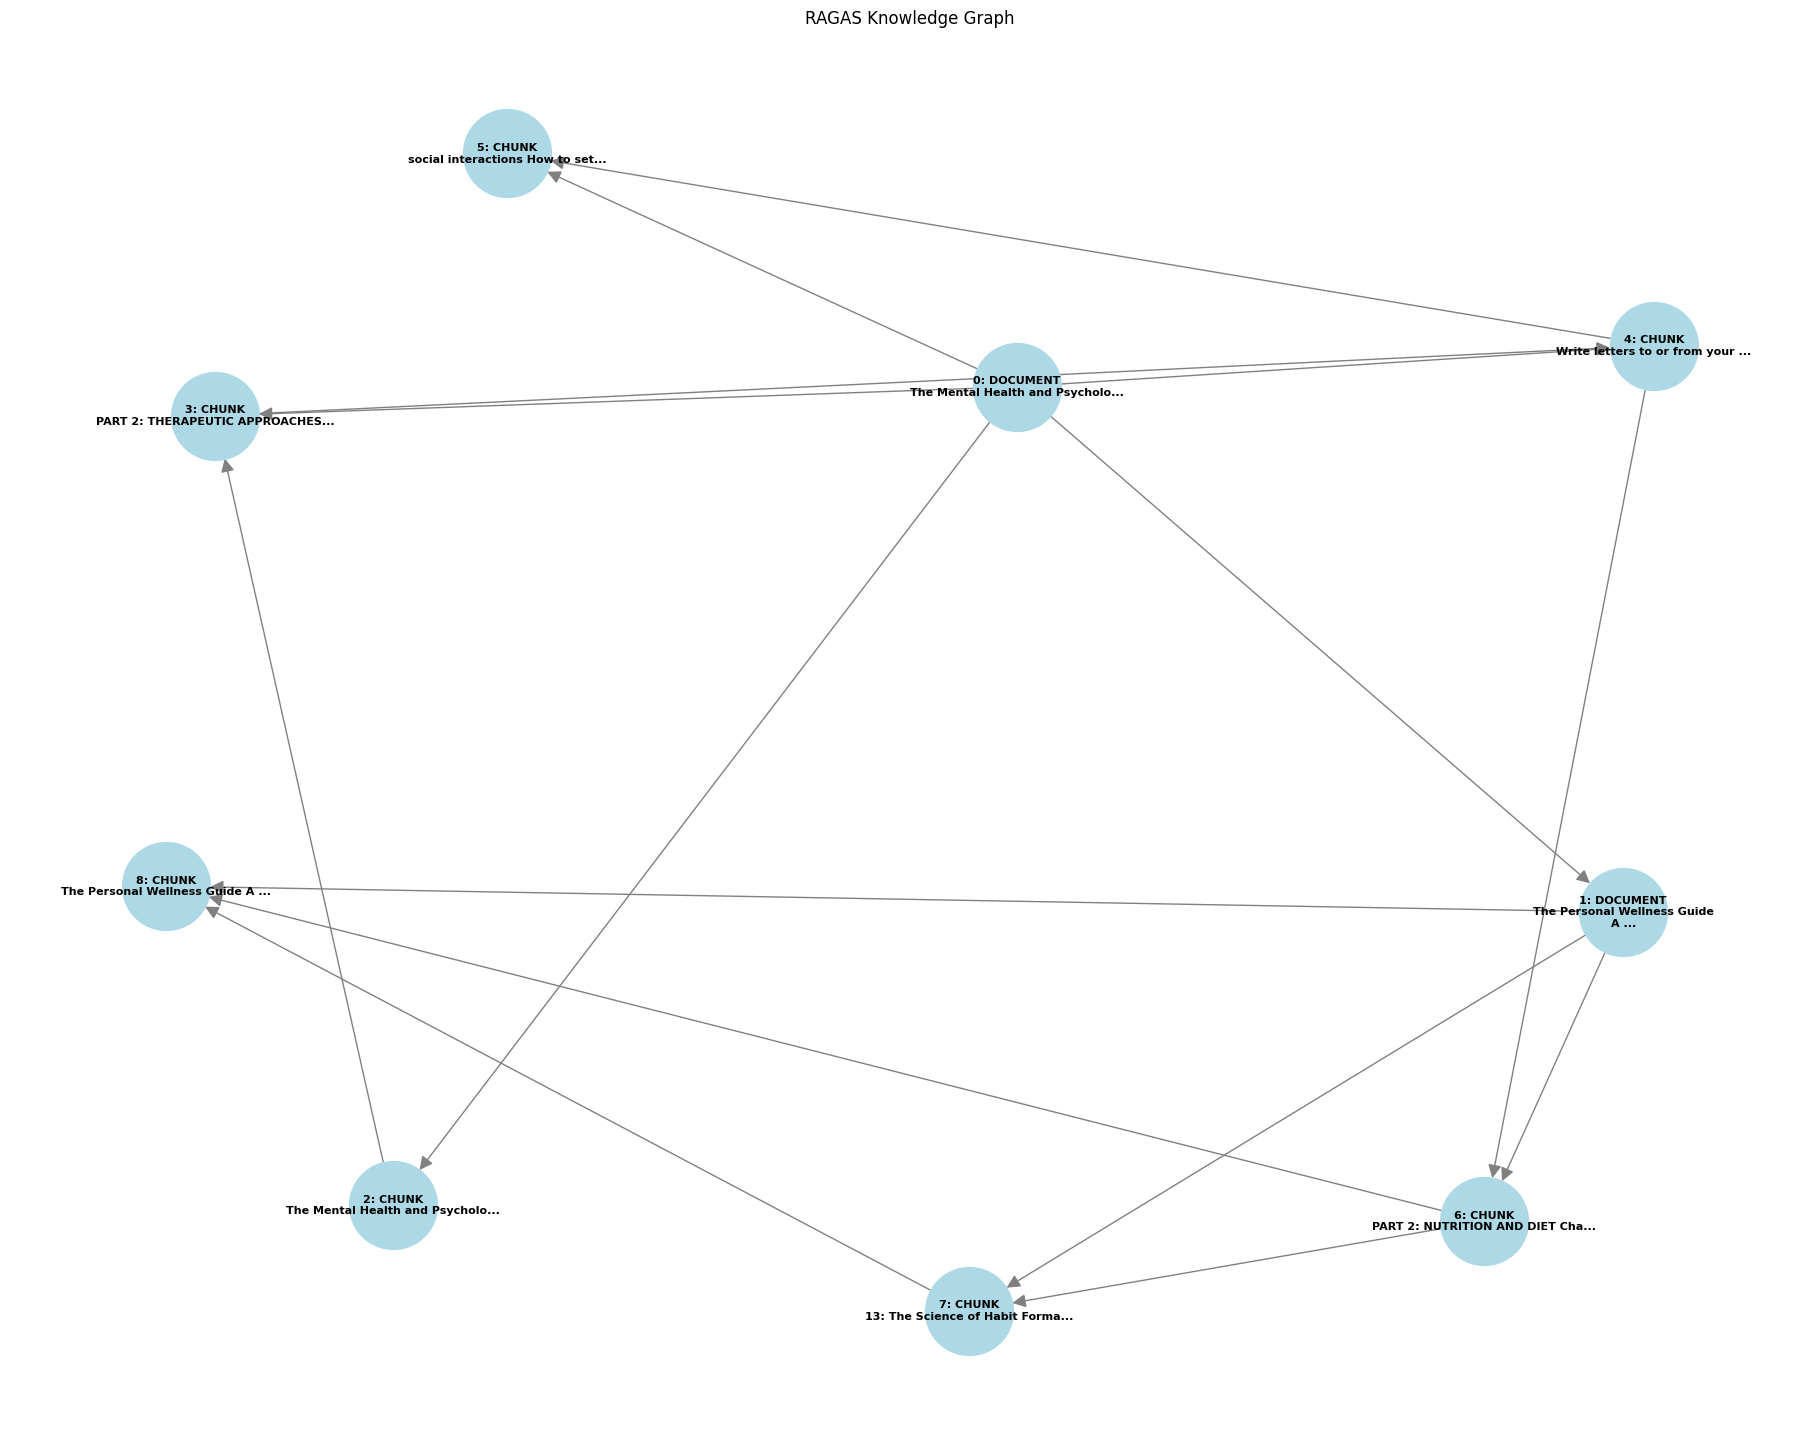

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Add nodes with meaningful labels
for i, node in enumerate(kg.nodes):
    node_type = str(node.type).split('.')[-1]

    # Create short label based on node type
    if 'page_content' in node.properties:
        label = f"{i}: {node_type}\n{node.properties['page_content'][:30]}..."
    elif 'summary' in node.properties:
        label = f"{i}: {node_type}\n{node.properties['summary'][:30]}..."
    else:
        label = f"{i}: {node_type}"

    G.add_node(i, label=label)

# Add edges
for rel in kg.relationships:
    source_idx = kg.nodes.index(rel.source)
    target_idx = kg.nodes.index(rel.target)
    G.add_edge(source_idx, target_idx)

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, k=4, iterations=100, seed=42)
labels = nx.get_node_attributes(G, 'label')
nx.draw(G, pos, labels=labels, with_labels=True, node_color='lightblue',
        node_size=4000, font_size=8, font_weight='bold', arrows=True,
        arrowsize=20, edge_color='gray')
plt.title("RAGAS Knowledge Graph")
plt.tight_layout()
plt.show()

In [ ]:
# child	"This chunk came from this document"	0 → 2 means Chunk 2 is from Document 0
# next	Sequential order within document	2 → 3 means Chunk 3 follows Chunk 2
# cosine_similarity	Embedding similarity (docs are related)	Documents 0 & 1 are topically similar
# entities_overlap	Share named entities (people, concepts, terms)

for rel in kg.relationships:
    print(f"{rel.type}: {kg.nodes.index(rel.source)} → {kg.nodes.index(rel.target)}")

child: 0 → 2
child: 0 → 3
child: 0 → 4
child: 0 → 5
next: 2 → 3
next: 3 → 4
next: 4 → 5
child: 1 → 6
child: 1 → 7
child: 1 → 8
next: 6 → 7
next: 7 → 8
cosine_similarity: 0 → 1
entities_overlap: 3 → 4
entities_overlap: 4 → 6
entities_overlap: 6 → 8


## ❓ Question #2:

Ragas offers both an "unrolled" (manual) approach and an "abstracted" (automatic) approach to synthetic data generation. What are the trade-offs between these two approaches? When would you choose one over the other?

##### Answer:
The automatic approach is great for prototyping and getting an test set of questions quickly boostrapped. The manual approach is good if you need fine-grained control over how the knowledge graph is constructed and what transformations are applied to enrich the knowledge graph (we used the default in our manual example, but we could need different ones). 

---
## 🏗️ Activity #1: Custom Query Distribution

Modify the `query_distribution` to experiment with different ratios of query types.

### Requirements:
1. Create a custom query distribution with different weights than the default
2. Generate a new test set using your custom distribution
3. Compare the types of questions generated with the default distribution
4. Explain why you chose the weights you did

In [ ]:
# Define a custom query distribution with different weights
# Generate a new test set and compare with the default
new_query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.1),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.6),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.3),
]

testset = generator.generate(testset_size=10, query_distribution=new_query_distribution)
testset.to_pandas()


Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,What mental health,[The Mental Health and Psychology Handbook A P...,"Mental health is our emotional, psychological,...",single_hop_specifc_query_synthesizer
1,How can build a workout routine that includes ...,[<1-hop>\n\nWrite letters to or from your futu...,To build a workout routine that supports menta...,multi_hop_abstract_query_synthesizer
2,how sleep cycles and stages like REM and non-R...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,"Sleep occurs in cycles of about 90 minutes, al...",multi_hop_abstract_query_synthesizer
3,How do mindfulness-based therapies support psy...,[<1-hop>\n\nThe Mental Health and Psychology H...,"Mindfulness-based therapies, such as Mindfulne...",multi_hop_abstract_query_synthesizer
4,How does the use of CBT techniques help improv...,[<1-hop>\n\nThe Mental Health and Psychology H...,The context explains that Cognitive Behavioral...,multi_hop_abstract_query_synthesizer
5,"How can understanding the habit loop of cue, r...",[<1-hop>\n\nPART 5: BUILDING HEALTHY HABITS Ch...,"Understanding the habit loop—comprising cue, r...",multi_hop_abstract_query_synthesizer
6,"How does the gut-brain axis, influenced by pro...",[<1-hop>\n\nThe Mental Health and Psychology H...,The gut-brain axis plays a significant role in...,multi_hop_abstract_query_synthesizer
7,"How does magnesium, as discussed in the contex...",[<1-hop>\n\nWrite letters to or from your futu...,"The context highlights that magnesium, found i...",multi_hop_specific_query_synthesizer
8,How do the foundational concepts introduced in...,[<1-hop>\n\nThe Personal Wellness Guide A Comp...,Chapter 1 emphasizes that regular physical act...,multi_hop_specific_query_synthesizer
9,How can incorporating CBT and mindfulness-base...,[<1-hop>\n\nPART 2: THERAPEUTIC APPROACHES Cha...,Integrating Cognitive Behavioral Therapy (CBT)...,multi_hop_specific_query_synthesizer


##### Answer:

**Activity 1 Reflection:**

I chose these weights (10% SingleHop, 60% MultiHopAbstract, 30% MultiHopSpecific) because I was interested in seeing a larger proportion of "multi-hop" questions. Compared to the outputs of the default distribution, my custom test set does include more complex questions requiring explanation or connection between multiple chunks, rather than simple fact retrieval or definitions.

We'll need to provide our LangSmith API key, and set tracing to "true".

---
# 🤝 Breakout Room #2
## RAG Evaluation with LangSmith

## Task 4: LangSmith Dataset

Now we can move on to creating a dataset for LangSmith!

First, we'll need to create a dataset on LangSmith using the `Client`!

We'll name our Dataset to make it easy to work with later.

In [28]:
from langsmith import Client
import uuid

client = Client()

dataset_name = f"Use Case Synthetic Data - AIE9 - {uuid.uuid4()}"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Synthetic Data for Use Cases"
)

We'll iterate through the RAGAS created dataframe - and add each example to our created dataset!

> NOTE: We need to conform the outputs to the expected format - which in this case is: `question` and `answer`.

In [29]:
for data_row in dataset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

## Basic RAG Chain

Time for some RAG!


In [30]:
rag_documents = docs

To keep things simple, we'll just use LangChain's recursive character text splitter!


In [31]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

We'll create our vectorstore using OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) embedding model.

In [32]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

As usual, we will power our RAG application with Qdrant!

In [33]:
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="use_case_rag"
)

In [34]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

To get the "A" in RAG, we'll provide a prompt.

In [35]:
from langchain_core.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".
Sing a little jingle if you're feeling extra excited about the question!
Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

As is usual: We'll be using `gpt-4.1-mini` for our RAG!

In [36]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

Finally, we can set-up our RAG LCEL chain!

In [37]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [38]:
rag_chain.invoke({"question" : "What are some recommended exercises for lower back pain?"})

'Here we go, a jingle just for you! 🎶\n\nFor lower back pain relief, here’s what you can do,  \nCat-Cow stretch and Bird Dog too!  \nPartial crunches, Knee-to-Chest, Pelvic Tilts, all true,  \nGentle moves to help comfort you!\n\nNow, based on the context, recommended exercises for lower back pain include:\n\n- **Cat-Cow Stretch**: Start on hands and knees, alternate between arching your back up (cat) and letting it sag down (cow). Do 10-15 repetitions.  \n- **Bird Dog**: From hands and knees, extend opposite arm and leg while keeping the core engaged. Hold for 5 seconds, then switch sides. Do 10 repetitions per side.  \n- **Partial Crunches**: Lie on your back with knees bent, cross arms over chest, tighten stomach muscles and raise shoulders off floor. Hold briefly, then lower. Do 8-12 repetitions.  \n- **Knee-to-Chest Stretch**: Lie on your back, pull one knee toward your chest while keeping the other foot flat. Hold for 15-30 seconds, then switch legs.  \n- **Pelvic Tilts**: Lie on

## LangSmith Evaluation Set-up

We'll use OpenAI's GPT-4.1 as our evaluation LLM for our base Evaluators.

In [39]:
eval_llm = ChatOpenAI(model="gpt-4.1")

We'll be using a number of evaluators - from LangSmith provided evaluators, to a few custom evaluators!

In [41]:
from openevals.llm import create_llm_as_judge
from langsmith.evaluation import evaluate

# 1. QA Correctness (replaces LangChainStringEvaluator("qa"))
qa_evaluator = create_llm_as_judge(
    prompt="You are evaluating a QA system. Given the input, assess whether the prediction is correct.\n\nInput: {inputs}\nPrediction: {outputs}\nReference answer: {reference_outputs}\n\nIs the prediction correct? Return 1 if correct, 0 if incorrect.",
    feedback_key="qa",
    model="openai:gpt-4o" ,  # pass your LangChain chat model directly
)

# 2. Labeled Helpfulness (replaces LangChainStringEvaluator("labeled_criteria"))
labeled_helpfulness_evaluator = create_llm_as_judge(
    prompt=(
        "You are assessing a submission based on the following criterion:\n\n"
        "helpfulness: Is this submission helpful to the user, "
        "taking into account the correct reference answer?\n\n"
        "Input: {inputs}\n"
        "Submission: {outputs}\n"
        "Reference answer: {reference_outputs}\n\n"
        "Does the submission meet the criterion? Return 1 if yes, 0 if no."
    ),
    feedback_key="helpfulness",
    model="openai:gpt-4o" ,
)

# 3. Dopeness (replaces LangChainStringEvaluator("criteria"))
dopeness_evaluator = create_llm_as_judge(
    prompt=(
        "You are assessing a submission based on the following criterion:\n\n"
        "dopeness: Is this response dope, lit, cool, or is it just a generic response?\n\n"
        "Input: {inputs}\n"
        "Submission: {outputs}\n\n"
        "Does the submission meet the criterion? Return 1 if yes, 0 if no."
    ),
    feedback_key="dopeness",
    model="openai:gpt-4o" ,
)

> **Describe what each evaluator is evaluating:**
>
> - `qa_evaluator`: assesses whether the response is correct by using the inputs, outputs, and the reference outputs in the test set.
> - `labeled_helpfulness_evaluator`: assesses how helpful the answer is to the user using the reference output in our test set. Does the RAG pipeline answer the question and provide the user with what they've asked for?
> - `dopeness_evaluator`: assesses the style of the response and evaluates how "dope" the response is - does it have personality, or is it just a standard, vanilla answer?

## LangSmith Evaluation

In [42]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'complicated-game-63' at:
https://smith.langchain.com/o/874885a0-7cbb-5ce0-827e-05c696e343d9/datasets/0abf0ff7-6229-4d53-bad6-fd1e851abad6/compare?selectedSessions=b67e92ba-df13-4dcb-a7a1-f9a64c8da8b4




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.qa,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,H0w cbt and cbt-i r rel8ed 2 mental health imp...,CBT (Cognitive Behavioral Therapy) improves me...,None,The context explains that Cognitive Behavioral...,True,True,False,2.716303,8afdbf9c-628b-4c91-8cc7-42ace3430ecf,019c5e24-9c63-7c60-86ae-3b95f73f644b
1,how chapter 8 and 14 relate to mental health a...,Chapter 8 is not explicitly mentioned in the p...,None,chapter 8 talks about sleep and recovery which...,False,False,True,3.172016,db1bc823-9238-4b55-88dd-0790faf9f39b,019c5e24-dd24-7fe1-993e-1b498c9f1f17
2,Wha chapter 2 and 8 tel about stres and sleep?,I don't know.,None,"Chapter 2 discusses stress, including its phys...",False,False,False,0.960117,7bf93dcf-26cf-4d1d-aa69-3ceff5560040,019c5e25-19c2-77a3-a909-df0165420902
3,how magnesium helps mental health and sleep an...,Magnesium helps mental health by regulating mo...,None,magnesium is important for mental health becau...,True,True,False,1.285663,c60f6157-0aab-4f02-a301-6062fa31cbf5,019c5e25-3f4e-7921-9f26-4586f0ccf586
4,How can practicing self-awareness through jour...,Practicing self-awareness through journaling a...,None,Practicing self-awareness through journaling a...,True,True,True,3.531226,ba614fa9-d59f-457d-9b49-3da2e26fa393,019c5e25-591b-73a2-8438-3ee22355f498
5,How does maintaining a consistent sleep schedu...,Maintaining a consistent sleep schedule contri...,None,Maintaining a consistent sleep schedule is a k...,True,True,False,1.633622,ee5c7f4b-bd45-408e-95d5-bf444060e56c,019c5e25-92c3-7b43-830d-ac0198a6f769
6,How can building a gradual workout routine tha...,Building a gradual workout routine that includ...,None,Building a gradual workout routine that incorp...,True,True,True,3.674144,bad6593a-9216-44b5-9059-6dfe92a1c889,019c5e25-b626-72f1-8609-f913a0e2bef7
7,"So, like, if I wanna get healthier and do meal...","Oh, this question makes me wanna sing! 🎵 Let's...",None,"Based on the Personal Wellness Guide, to suppo...",True,True,True,5.968490,3737ec6a-35e1-4c2a-b65d-85306d89d016,019c5e25-e834-7e90-b681-3e0a8f906422
8,How does FOMO contribute to mental health chal...,FOMO (Fear of Missing Out) contributes to ment...,None,Fear of missing out (FOMO) drives compulsive c...,True,True,False,1.787601,4d37b169-8bd9-41b8-a5fc-1146b2ed7f49,019c5e26-239e-77c3-9136-eacead43f16a
9,"How does sleep influence mental health, and wh...",Sleep influences mental health in several impo...,None,Sleep and mental health have a bidirectional r...,True,True,True,2.357465,2ade9743-ab3d-442d-9e81-043b2cf36a41,019c5e26-46af-7173-943c-42a198f10705


## Dope-ifying Our Application

We'll be making a few changes to our RAG chain to increase its performance on our SDG evaluation test dataset!

- Include a "dope" prompt augmentation
- Use larger chunks
- Improve the retriever model to: `text-embedding-3-large`

Let's see how this changes our evaluation!

In [51]:
DOPENESS_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Make your answer rad, ensure high levels of dopeness. Do not be generic, or give generic responses.

Context: {context}
Question: {question}
"""

dopeness_rag_prompt = ChatPromptTemplate.from_template(DOPENESS_RAG_PROMPT)

In [52]:
rag_documents = docs

In [53]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

## ❓ Question #3:

Why would modifying our chunk size modify the performance of our application?

##### Answer:
Doubling our chunk size from 500 -> 1000 can change the performance because we are returning more context for the LLM during retrieval. This could be helpful, giving our LLM greater information to work off of and potentially leading to more cohesive answers if concepts are on chunk boundaries. However, it might also lead to more irrelevant information being passed in the context window, and if we are using the same embeddings, might "dilute" the meaning of the chunk. Essentially, we are making a tradeoff between precision with smaller chunks vs more context around the matching content.

In [54]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

## ❓ Question #4:

Why would modifying our embedding model modify the performance of our application?

##### Answer:
Moving to a larger, more powerful embedding model means we can encode more meaning into our embeddings, capturing more nuance and detail than the smaller embedding model. In theory, this can improve semantic search quality, as the embeddings better represent the document chunks, and capture more nuance and precision in user queries. This should lead to better retrievals, at the cost of speed and money.

In [55]:
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG Docs"
)

In [56]:
retriever = vectorstore.as_retriever()

Setting up our new and improved DOPE RAG CHAIN.

In [57]:
dopeness_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | dopeness_rag_prompt | llm | StrOutputParser()
)

Let's test it on the same output that we saw before.

In [58]:
dopeness_rag_chain.invoke({"question" : "How can I improve my sleep quality?"})

'Alright, listen up! If you want to upgrade your sleep game to legendary status, here’s your ultimate cheat code straight from the sleep vault:\n\n1. **Lock Down Your Sleep Schedule** – Hit the sack and wake up at the same time every dang day, yes—even on weekends. Your body loves rhythm like a DJ loves beats.\n\n2. **Ritualize Your Wind-Down** – Craft a pre-bedtime ritual that signals “chill mode activated.” Think soft reading, gentle stretches, or a warm bath that’s basically a hug from the inside.\n\n3. **Zen Your Bedroom Vibes** – Keep that room cool—65 to 68°F (18-20°C) is the sweet spot. Seal darkness with blackout curtains or a sleep mask, and drown out distractions with white noise or earplugs. Upgrade your throne—quality mattress and pillows —your body deserves it.\n\n4. **Screen Time Curfew** – Shut down your gadgets at least 1-2 hours before bed. Blue light is sneaky, messing with your melatonin like a party crasher.\n\n5. **Caffeine Curfew** – No caffeine after 2 PM unless 

Finally, we can evaluate the new chain on the same test set!

In [59]:
evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'roasted-bibliography-66' at:
https://smith.langchain.com/o/874885a0-7cbb-5ce0-827e-05c696e343d9/datasets/0abf0ff7-6229-4d53-bad6-fd1e851abad6/compare?selectedSessions=488e200d-54fc-4352-9c2c-3ea9f5046e72




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.qa,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,H0w cbt and cbt-i r rel8ed 2 mental health imp...,"Alright, let’s break it down with max rad clar...",None,The context explains that Cognitive Behavioral...,True,True,True,3.521580,8afdbf9c-628b-4c91-8cc7-42ace3430ecf,019c5e34-3e30-7f52-ae4b-82c8e7967950
1,how chapter 8 and 14 relate to mental health a...,"Alright, let’s crank the dopamine and vibe-che...",None,chapter 8 talks about sleep and recovery which...,False,False,True,7.820111,db1bc823-9238-4b55-88dd-0790faf9f39b,019c5e34-7207-7a22-98f6-0772f370c957
2,Wha chapter 2 and 8 tel about stres and sleep?,"Alright, let’s crank up the dopeness! Based on...",None,"Chapter 2 discusses stress, including its phys...",False,False,True,4.317412,7bf93dcf-26cf-4d1d-aa69-3ceff5560040,019c5e34-c852-7553-b69c-120b50c0e207
3,how magnesium helps mental health and sleep an...,Magnesium is like the ultimate chill-pill mine...,None,magnesium is important for mental health becau...,True,True,True,2.310634,c60f6157-0aab-4f02-a301-6062fa31cbf5,019c5e35-09bc-7611-9390-dc77d083c3bd
4,How can practicing self-awareness through jour...,"Alright, here’s the rad scoop straight from th...",None,Practicing self-awareness through journaling a...,True,True,True,4.086583,ba614fa9-d59f-457d-9b49-3da2e26fa393,019c5e35-3b38-78f2-a8a1-6634ea86dff8
5,How does maintaining a consistent sleep schedu...,"Yo, listen up! Locking in a consistent sleep s...",None,Maintaining a consistent sleep schedule is a k...,True,True,True,2.460296,ee5c7f4b-bd45-408e-95d5-bf444060e56c,019c5e35-7fbc-7d21-a985-04a28b4bea26
6,How can building a gradual workout routine tha...,"Alright, strap in because we’re about to unloc...",None,Building a gradual workout routine that incorp...,True,True,True,5.692932,bad6593a-9216-44b5-9059-6dfe92a1c889,019c5e35-aa21-7160-b06b-0c1778312f64
7,"So, like, if I wanna get healthier and do meal...","Yo, you’re weaving the ultimate wellness tapes...",None,"Based on the Personal Wellness Guide, to suppo...",True,True,True,5.702536,3737ec6a-35e1-4c2a-b65d-85306d89d016,019c5e35-ed42-7542-9c18-2814d901f8d4
8,How does FOMO contribute to mental health chal...,"Oh, buckle up for this one—FOMO (Fear of Missi...",None,Fear of missing out (FOMO) drives compulsive c...,True,True,True,2.217935,4d37b169-8bd9-41b8-a5fc-1146b2ed7f49,019c5e36-2fe3-7993-82a0-17ef4d639570
9,"How does sleep influence mental health, and wh...","Alright, strap in for the sleep-mental health ...",None,Sleep and mental health have a bidirectional r...,True,True,True,5.171236,2ade9743-ab3d-442d-9e81-043b2cf36a41,019c5e36-51df-76f3-8502-b9f560147b20


---
## 🏗️ Activity #2: Analyze Evaluation Results

Provide a screenshot of the difference between the two chains in LangSmith, and explain why you believe certain metrics changed in certain ways.

##### Answer:

![Chain Comparison](chain-comparison.png)

The modified chain (B) saw a large improvemt in dopeness (~0.5 -> ~0.85), and similar levels of helpfulness and QA correctness (~0.83). The modified chain also took roughly 2x slower, was 2.5x more expensive, and generated more tokens. 

- Dopeness increased because the prompt encouraged "dope" responses from the LLM. 
- QA and helpfulness both stayed roughly the same, which is good - despite the dramatic response style change, the answers were still similarly accurate to our baseline chain. While I was expecting to see some improvements in QA and helpfulness due to the chunking and embedding model changes, those changes don't appear to have really moved the needle at all on those metrics. It's possible we'd need to test this on a more complex, larger dataset with more complicated queries to see the effect of those changes.

---
## Summary

In this session, we:

1. **Generated synthetic test data** using Ragas' knowledge graph-based approach
2. **Explored query synthesizers** for creating diverse question types
3. **Loaded synthetic data** into a LangSmith dataset for evaluation
4. **Built and evaluated a RAG chain** using LangSmith evaluators
5. **Iterated on the pipeline** by modifying chunk size, embedding model, and prompt — then measured the impact

### Key Takeaways:

- **Synthetic data generation** is critical for early iteration — it provides high-quality signal without manually creating test data
- **LangSmith evaluators** enable systematic comparison of pipeline versions
- **Small changes matter** — chunk size, embedding model, and prompt modifications can significantly affect evaluation scores